# Flight Booking Sales Analysis

In [1]:
# import python libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt # visualizing data
%matplotlib inline
import seaborn as sns

In [2]:
# import csv files
bookings = pd.read_csv('big_databooking.csv', sep=';')
flights = pd.read_csv('big_dataflights.csv', sep=';')
passengers = pd.read_csv('big_datapassenger.csv', sep=';')

In [3]:
bookings.shape

(10500, 8)

In [4]:
bookings.head()

,booking_id,pnr,passenger_id,flight_id,seats,total_price,status,booking_date
0,1,PNR10001,1,1,1,9000.0,CONFIRMED,2026-06-01 10:01:00
1,2,PNR10002,2,2,2,9000.0,CONFIRMED,2026-06-01 10:02:00
2,3,PNR10003,3,3,3,9000.0,CONFIRMED,2026-06-01 10:03:00
3,4,PNR10004,4,4,4,9000.0,CONFIRMED,2026-06-01 10:04:00
4,5,PNR10005,5,5,5,9000.0,CONFIRMED,2026-06-01 10:05:00


In [5]:
flights.shape

(500, 10)

In [6]:
flights.head()

,flight_id,flight_no,source,destination,departure_time,arrival_time,price,seats_available,status,flight_name
0,52,AI201,Delhi,Dubai,2026-07-01 10:00:00,2026-07-01 12:30:00,18000.0,150,ACTIVE,Air India AI201
1,53,EK202,Mumbai,London,2026-07-01 02:00:00,2026-07-01 08:00:00,65000.0,200,ACTIVE,Emirates EK202
2,54,QR203,Delhi,Doha,2026-07-01 03:00:00,2026-07-01 04:30:00,22000.0,180,ACTIVE,Qatar QR203
3,55,SQ204,Chennai,Singapore,2026-07-01 05:00:00,2026-07-01 11:30:00,28000.0,160,ACTIVE,Singapore SQ204
4,56,BA205,Delhi,London,2026-07-01 01:00:00,2026-07-01 07:30:00,70000.0,220,ACTIVE,British BA205


In [7]:
bookings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10500 entries, 0 to 10499
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   booking_id    10500 non-null  int64  
 1   pnr           10500 non-null  object 
 2   passenger_id  10500 non-null  int64  
 3   flight_id     10500 non-null  int64  
 4   seats         10500 non-null  int64  
 5   total_price   10500 non-null  float64
 6   status        10500 non-null  object 
 7   booking_date  10500 non-null  object 
dtypes: float64(1), int64(4), object(3)
memory usage: 656.4+ KB


## Data Cleaning

In [8]:
# check for null values
pd.isnull(bookings).sum()

booking_id      0
pnr             0
passenger_id    0
flight_id       0
seats           0
total_price     0
status          0
booking_date    0
dtype: int64

In [9]:
# check for null values in flights
pd.isnull(flights).sum()

flight_id          0
flight_no          0
source             0
destination        0
departure_time     0
arrival_time       0
price              0
seats_available    0
status             0
flight_name        0
dtype: int64

In [10]:
# convert booking_date to datetime
bookings['booking_date'] = pd.to_datetime(bookings['booking_date'])
bookings['booking_date'].dtypes

dtype('<M8[ns]')

*Note: the first 500 rows of this booking data were originally seeded as test data, so a handful of rows have `seats` values as high as 100 (used to test the system, not real customer bookings). These are kept in the dataset below since they don't affect the overall trends, but worth knowing if a few outliers look unusually large in the seats column.*

In [11]:
# describe() returns count, mean, std, etc for numeric columns
bookings[['seats', 'total_price']].describe()

,seats,total_price
count,10500.000000,10500.000000
mean,5.743905,123026.476190
std,11.941472,133093.700389
min,1.000000,4500.000000
25%,2.000000,24500.000000
50%,4.000000,73500.000000
75%,5.000000,172000.000000
max,100.000000,588000.000000


## Merging Bookings with Flight Routes

Each booking only stores a `flight_id`, so to analyze routes, airlines, and source/destination we merge bookings with the flights table.

In [12]:
# merge bookings with flight route info
df = bookings.merge(flights, on='flight_id', how='left', suffixes=('', '_flight'))
df.shape

(10500, 17)

In [13]:
# how many bookings successfully matched a flight route
df['source'].notna().sum()

np.int64(9019)

*Some `flight_id` values in the bookings data don't have a matching row in the flights table (likely older test bookings referencing flights that were later replaced). These rows are kept for booking-level analysis (status, price, seats) but will show up as blank in route/airline-level charts.*

In [14]:
# extract airline code from flight number and map to airline name
df['airline_code'] = df['flight_no'].str.extract(r'^([A-Z0-9]{2})')

airline_names = {
    'AI': 'Air India', '6E': 'IndiGo', 'UK': 'Vistara', 'SG': 'SpiceJet', 'QP': 'Akasa',
    'EK': 'Emirates', 'QR': 'Qatar Airways', 'BA': 'British Airways', 'AF': 'Air France',
    'LH': 'Lufthansa', 'AA': 'American Airlines', 'JL': 'Japan Airlines', 'CX': 'Cathay Pacific',
    'TK': 'Turkish Airlines', 'EY': 'Etihad', 'SQ': 'Singapore Airlines'
}
df['airline'] = df['airline_code'].map(airline_names)

# classify each booking as Domestic or International based on destination
indian_cities = {'Ahmedabad','Bangalore','Chennai','Delhi','Goa','Hyderabad',
                  'Jaipur','Kolkata','Lucknow','Mumbai','Pune'}
df['trip_type'] = df['destination'].apply(
    lambda x: 'Domestic' if x in indian_cities else ('International' if pd.notna(x) else None)
)
df[['flight_no', 'airline', 'source', 'destination', 'trip_type']].head()

,flight_no,airline,source,destination,trip_type
0,NaN,NaN,NaN,NaN,None
1,NaN,NaN,NaN,NaN,None
2,NaN,NaN,NaN,NaN,None
3,NaN,NaN,NaN,NaN,None
4,NaN,NaN,NaN,NaN,None


# Exploratory Data Analysis

### Booking Status

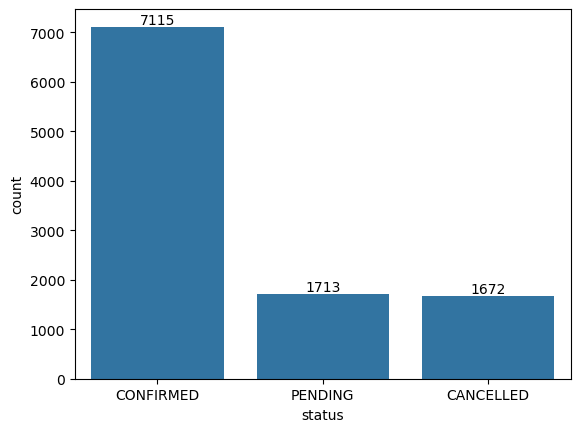

In [15]:
# plotting a bar chart for booking Status and its count
ax = sns.countplot(x='status', data=bookings)
for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='status', ylabel='total_price'>

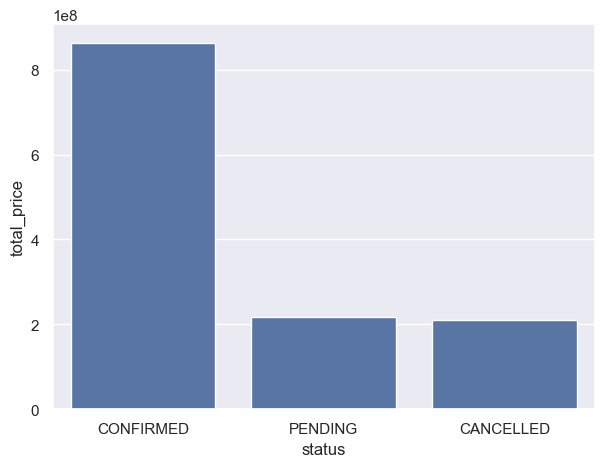

In [16]:
# plotting a bar chart for status vs total revenue
sales_status = bookings.groupby(['status'], as_index=False)['total_price'].sum().sort_values(by='total_price', ascending=False)

sns.set(rc={'figure.figsize':(7,5)})
sns.barplot(x='status', y='total_price', data=sales_status)

*From above graphs we can see that most bookings are Confirmed, and confirmed bookings account for the large majority of total revenue, while Cancelled and Pending bookings contribute comparatively little.*

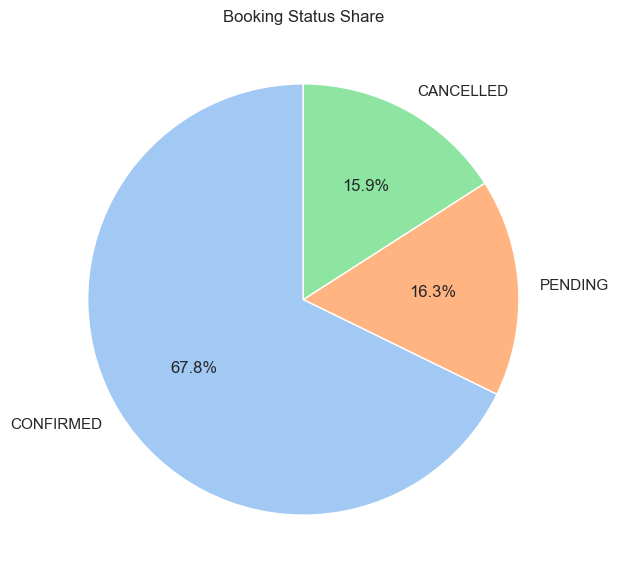

In [17]:
# pie chart: share of bookings by status
status_counts = bookings['status'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=90,
        colors=sns.color_palette('pastel'))
plt.title('Booking Status Share')
plt.show()

### Seats per Booking

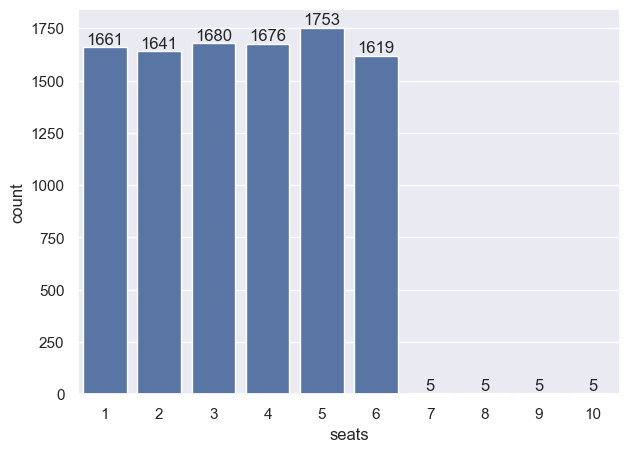

In [18]:
# distribution of seats booked per transaction (excluding test outliers above 10 for a clearer view)
ax = sns.countplot(x='seats', data=bookings[bookings['seats'] <= 10])
for bars in ax.containers:
    ax.bar_label(bars)

*Most bookings are for 1 to 6 seats per transaction, which lines up with typical solo, couple, and family/group travel bookings.*

### Domestic vs International Travel

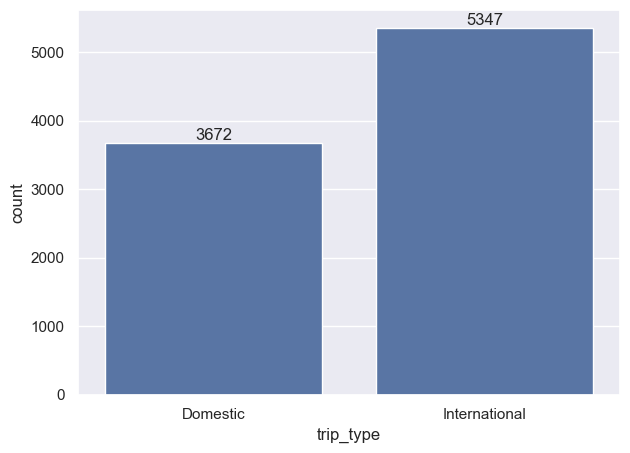

In [19]:
# plotting a bar chart for Domestic vs International trip count
trip_df = df.dropna(subset=['trip_type'])

ax = sns.countplot(x='trip_type', data=trip_df)
for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='trip_type', ylabel='total_price'>

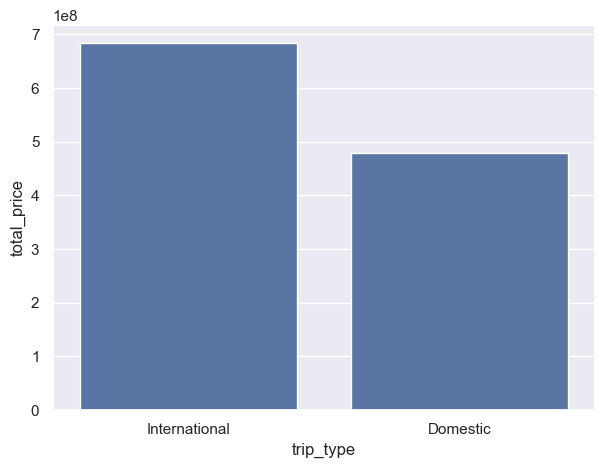

In [20]:
# total revenue: Domestic vs International
trip_rev = trip_df.groupby(['trip_type'], as_index=False)['total_price'].sum().sort_values(by='total_price', ascending=False)

sns.set(rc={'figure.figsize':(7,5)})
sns.barplot(x='trip_type', y='total_price', data=trip_rev)

*From above graphs we can see that International trips are booked more often and generate significantly higher revenue than Domestic trips, which makes sense given international fares are priced much higher per seat.*

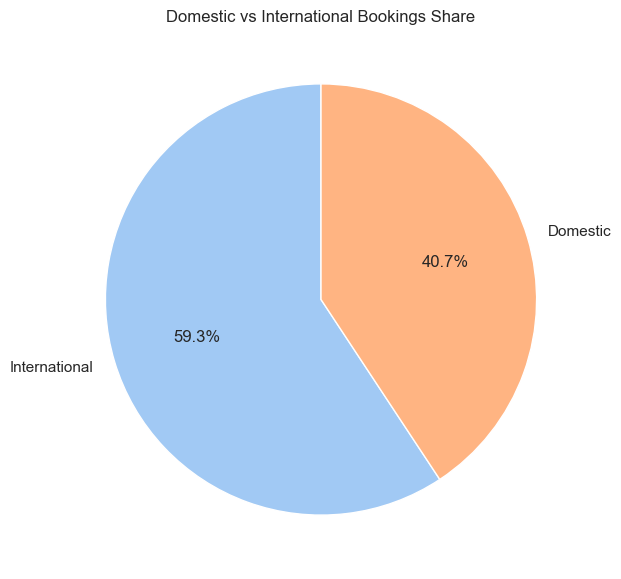

In [21]:
# pie chart: share of Domestic vs International bookings
trip_counts = trip_df['trip_type'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(trip_counts, labels=trip_counts.index, autopct='%1.1f%%', startangle=90,
        colors=sns.color_palette('pastel'))
plt.title('Domestic vs International Bookings Share')
plt.show()

### Top Routes

<Axes: xlabel='booking_id', ylabel='route'>

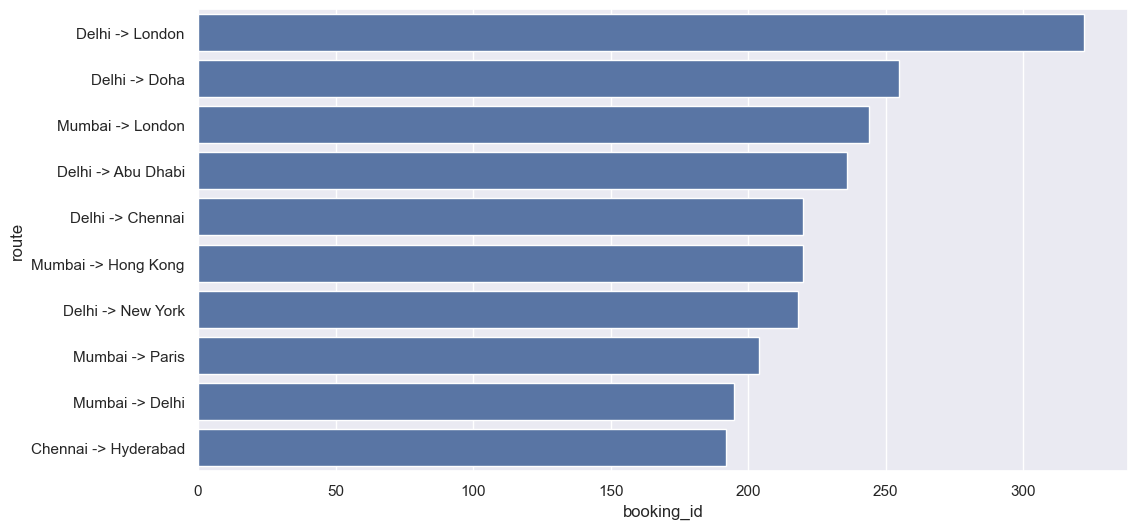

In [22]:
# top 10 routes by number of bookings
df['route'] = df['source'] + ' -> ' + df['destination']
route_orders = df.dropna(subset=['route']).groupby(['route'], as_index=False)['booking_id'].count().sort_values(by='booking_id', ascending=False).head(10)

sns.set(rc={'figure.figsize':(12,6)})
sns.barplot(x='booking_id', y='route', data=route_orders)

<Axes: xlabel='total_price', ylabel='route'>

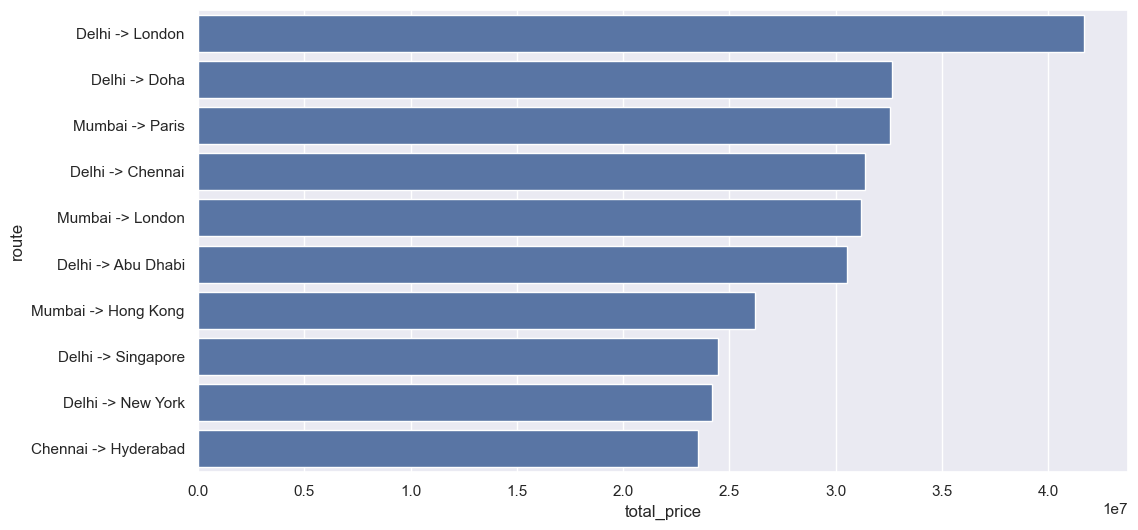

In [23]:
# top 10 routes by total revenue
route_rev = df.dropna(subset=['route']).groupby(['route'], as_index=False)['total_price'].sum().sort_values(by='total_price', ascending=False).head(10)

sns.set(rc={'figure.figsize':(12,6)})
sns.barplot(x='total_price', y='route', data=route_rev)

*From above graphs we can see that Delhi-London, Delhi-Doha and Mumbai-London are some of the most frequently booked and highest revenue-generating routes.*

### Airlines

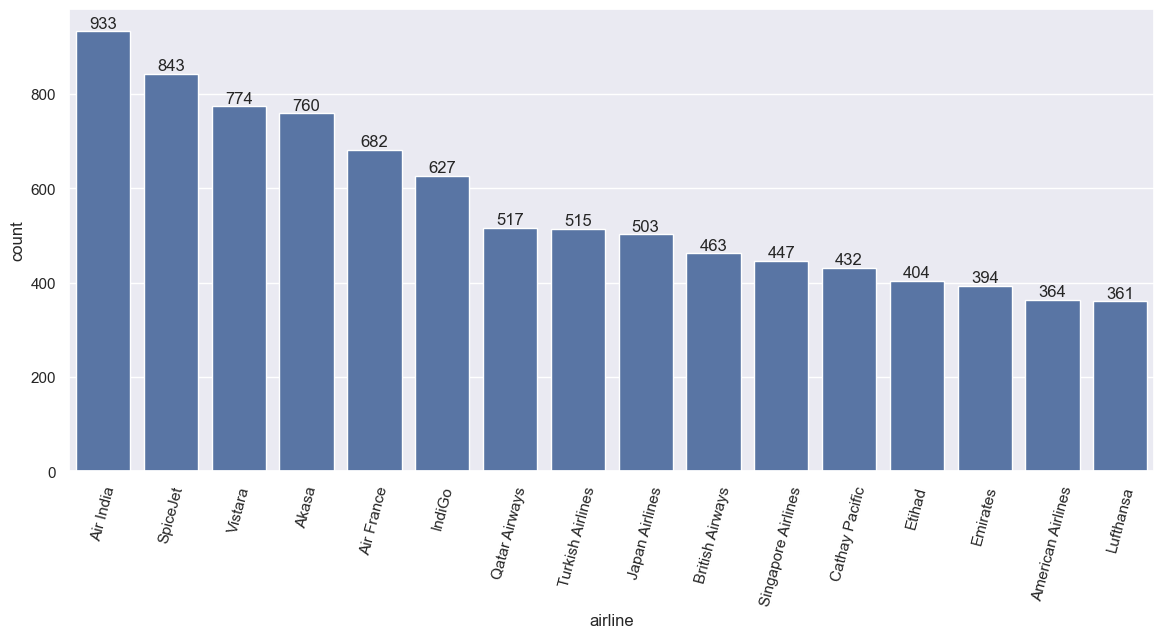

In [24]:
# number of bookings per airline
sns.set(rc={'figure.figsize':(14,6)})
ax = sns.countplot(x='airline', data=df.dropna(subset=['airline']), order=df['airline'].value_counts().index)
ax.tick_params(axis='x', rotation=75)
for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='total_price', ylabel='airline'>

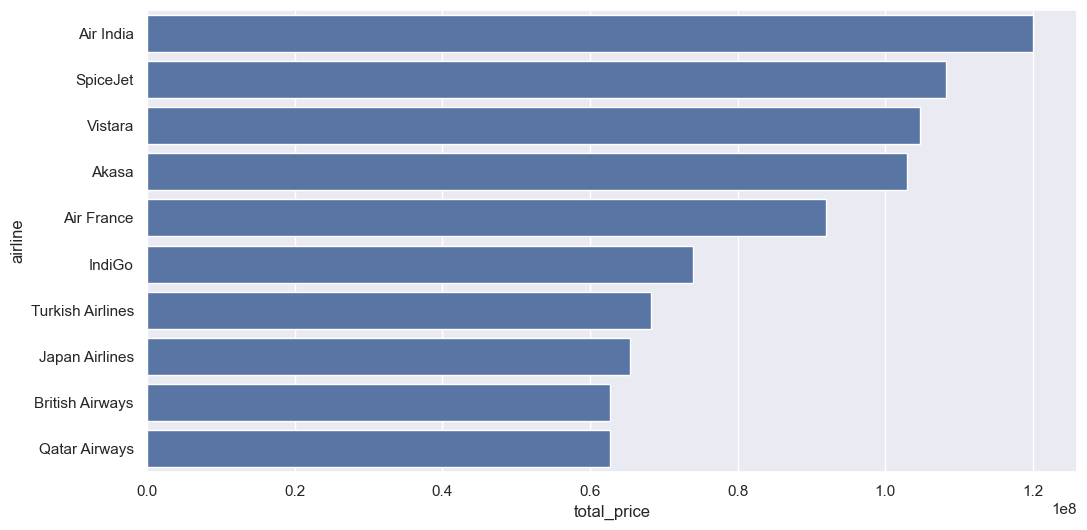

In [25]:
# top 10 airlines by total revenue
airline_rev = df.dropna(subset=['airline']).groupby(['airline'], as_index=False)['total_price'].sum().sort_values(by='total_price', ascending=False).head(10)

sns.set(rc={'figure.figsize':(12,6)})
sns.barplot(x='total_price', y='airline', data=airline_rev)

*Air India, SpiceJet and Vistara have the highest number of bookings, while the long-haul international carriers contribute disproportionately more revenue per booking due to higher ticket prices.*

### Daily Booking Trend

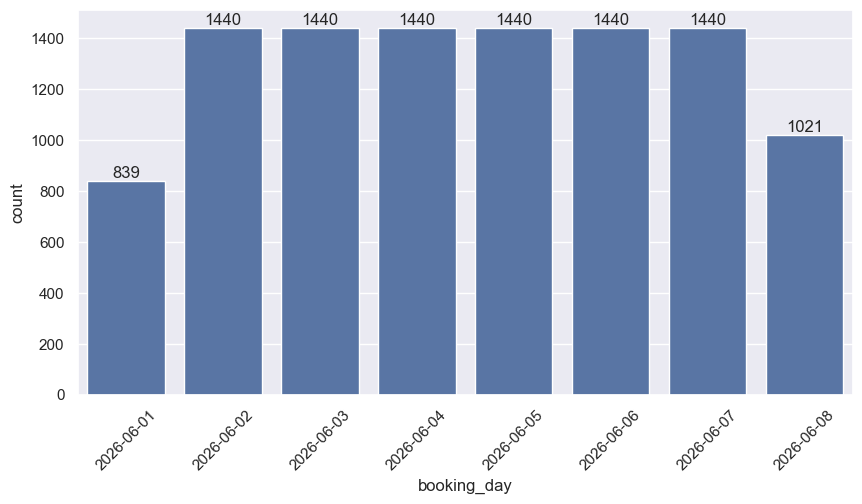

In [26]:
# bookings made per day
bookings['booking_day'] = bookings['booking_date'].dt.date

sns.set(rc={'figure.figsize':(10,5)})
ax = sns.countplot(x='booking_day', data=bookings)
ax.tick_params(axis='x', rotation=45)
for bars in ax.containers:
    ax.bar_label(bars)

*Booking volume is fairly steady across the days in this dataset, with the first and last days showing slightly fewer bookings since the data window starts and ends mid-day.*

### Passenger Data Coverage

In [27]:
# check how many bookings have a matching passenger record
matched_passengers = bookings['passenger_id'].isin(passengers['passenger_id']).sum()
total_bookings = bookings.shape[0]

print(f"Bookings with a matching passenger record: {matched_passengers} out of {total_bookings}")

Bookings with a matching passenger record: 0 out of 10500


*Note: the `passenger_id` values referenced in this booking data (1-500) don't overlap with the `passenger_id` range in the passenger CSV provided (2012-12511), so a direct merge between bookings and passengers isn't possible with the current data. Once both datasets are generated from the same source (i.e. the passenger IDs referenced in bookings actually exist in the passenger table), this section can be extended to analyze gender, nationality, and age-based buying patterns — similar to the customer demographics analysis in the original Diwali Sales notebook.*

## Conclusion:

### 

*Most bookings are Confirmed and international routes out of Delhi and Mumbai — especially to London, Doha and the Gulf — drive both the highest booking volumes and the highest revenue. Air India, SpiceJet and Vistara lead in number of bookings, while long-haul international carriers lead in revenue per booking due to higher fares.*

Thank you!